In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import math
from tqdm import tqdm

import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline

from position_tools import calculate_trades, calculate_positions

In [2]:
def load_json_candles(fname):
    data = pd.read_json(fname)
    data.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')
    data.set_index('timestamp', inplace=True)
    return data

def load_candles(exchange,base,quote,timeframe):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/{base}_{quote}-{timeframe}.json'
    return load_json_candles(fname)

def load_futures_candles(exchange,base,quote,timeframe):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/futures/{base}_{quote}_{quote}-{timeframe}-futures.json'
    return load_json_candles(fname)

def load_sp500_stock_candles(ticker):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/sp500_data/{ticker}.csv'
    data = pd.read_csv(fname)
    data['Date'] = pd.to_datetime(data.Date)
    data.columns = [c.lower() for c in data.columns]
    data.set_index('date', inplace=True)
    return data

def load_russel2000_candles(ticker):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/russell_2000_data/{ticker}.csv'
    data = pd.read_csv(fname)
    data['Date'] = pd.to_datetime(data.Date)
    data.columns = [c.lower() for c in data.columns]
    data.set_index('date', inplace=True)
    return data

In [3]:
print(np.get_include())
# gcc -shared -o positions.so -fPIC positions.c -I/home/mu6mula/miniconda3/envs/py310/include/python3.10 -I/home/mu6mula/miniconda3/envs/py310/include/python3.10 -I/home/mu6mula/miniconda3/envs/py310/lib/python3.10/site-packages/numpy/core/include

/home/mu6mula/miniconda3/envs/py310/lib/python3.10/site-packages/numpy/core/include


aparams = [{'up_lookback': 192, 'dn_lookback': 130, 'up_lag': 69, 'dn_lag': 196, 'band_offset': 0.5947789836090155}, {'up_lookback': 155, 'dn_lookback': 194, 'up_lag': 15, 'dn_lag': 147, 'band_offset': 0.46172899188621264}, {'up_lookback': 155, 'dn_lookback': 157, 'up_lag': 123, 'dn_lag': 196, 'band_offset': 0.5947789836090155}]
params = {'up_lookback': 192, 'dn_lookback': 130, 'up_lag': 69, 'dn_lag': 196, 'band_offset': 0.5947789836090155}
Total Return: 2.87
Asset Return: -0.54
Sharpe Ratio: 0.04
# Trades: 16
# Wins: 7
# Losses: 10
Win Ratio: 0.44
Profit Factor: 4.42
Win Ratio: 0.44
Average Win: 0.3314
Average Loss: -0.0525
Average DrawDown: -0.0449
Max DrawDown: -0.1914


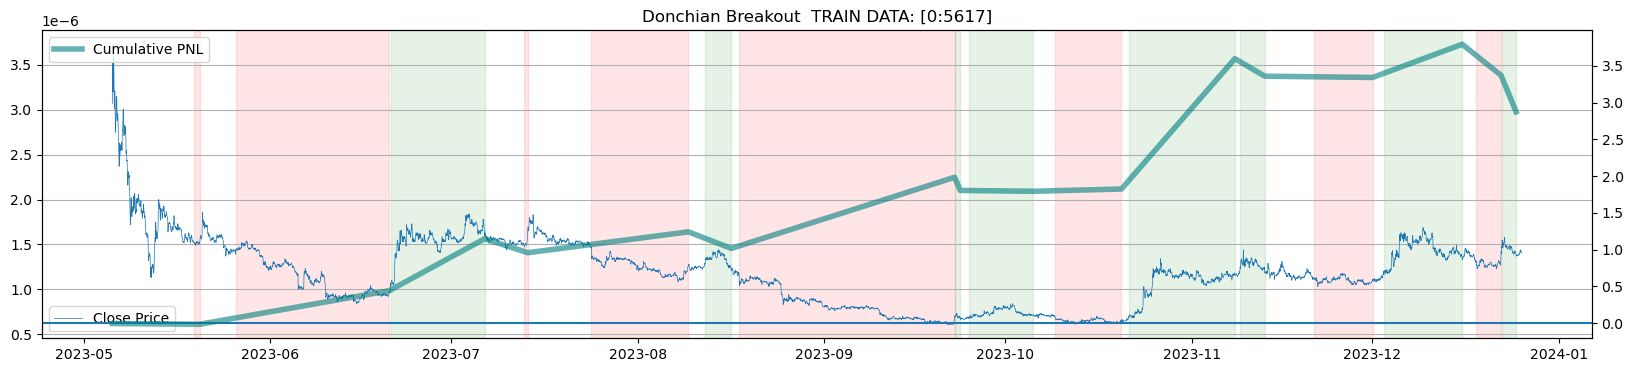

Total Return: 12.67
Asset Return: 4.33
Sharpe Ratio: 0.04
# Trades: 15
# Wins: 9
# Losses: 7
Win Ratio: 0.60
Profit Factor: 10.71
Win Ratio: 0.60
Average Win: 0.8861
Average Loss: -0.1064
Average DrawDown: -0.1012
Max DrawDown: -0.2948


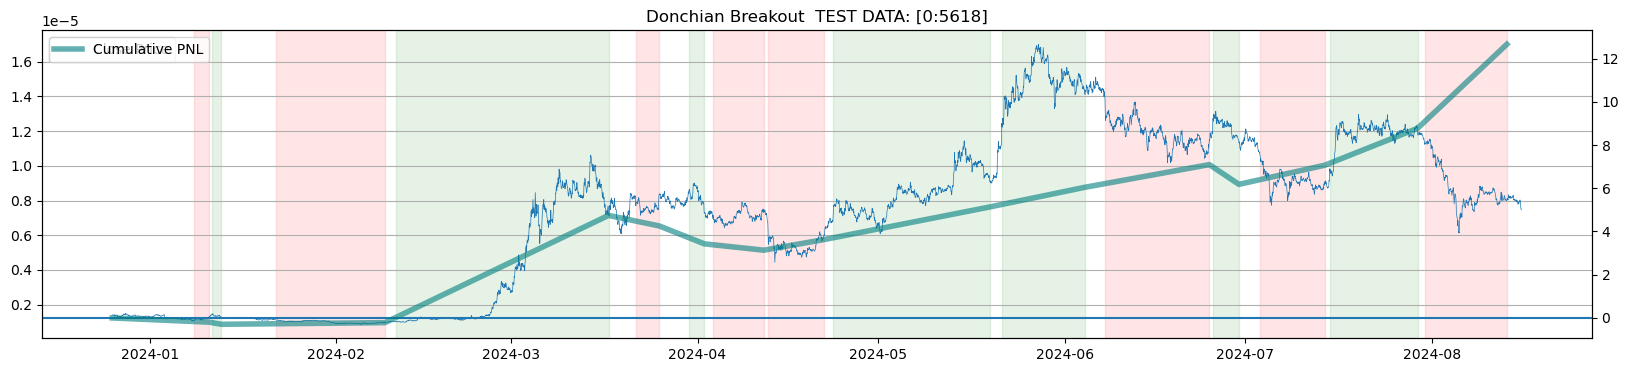

params = {'up_lookback': 155, 'dn_lookback': 194, 'up_lag': 15, 'dn_lag': 147, 'band_offset': 0.46172899188621264}
Total Return: 2.50
Asset Return: -0.54
Sharpe Ratio: 0.04
# Trades: 19
# Wins: 7
# Losses: 13
Win Ratio: 0.37
Profit Factor: 3.83
Win Ratio: 0.37
Average Win: 0.3284
Average Loss: -0.0462
Average DrawDown: -0.0528
Max DrawDown: -0.1744


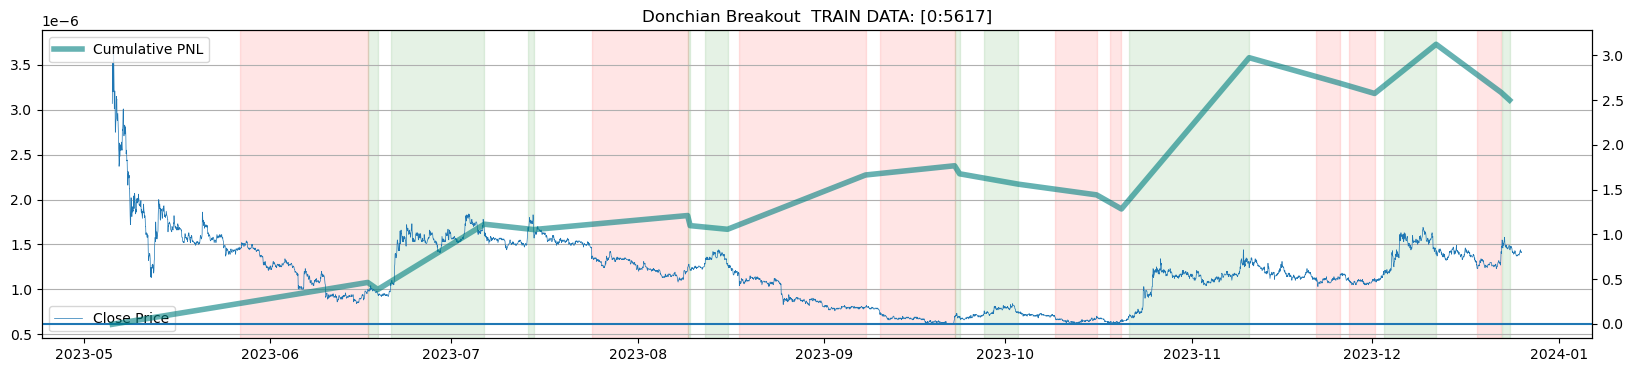

Total Return: 9.74
Asset Return: 4.33
Sharpe Ratio: 0.05
# Trades: 20
# Wins: 13
# Losses: 8
Win Ratio: 0.65
Profit Factor: 9.01
Win Ratio: 0.65
Average Win: 0.4430
Average Loss: -0.0799
Average DrawDown: -0.0525
Max DrawDown: -0.2499


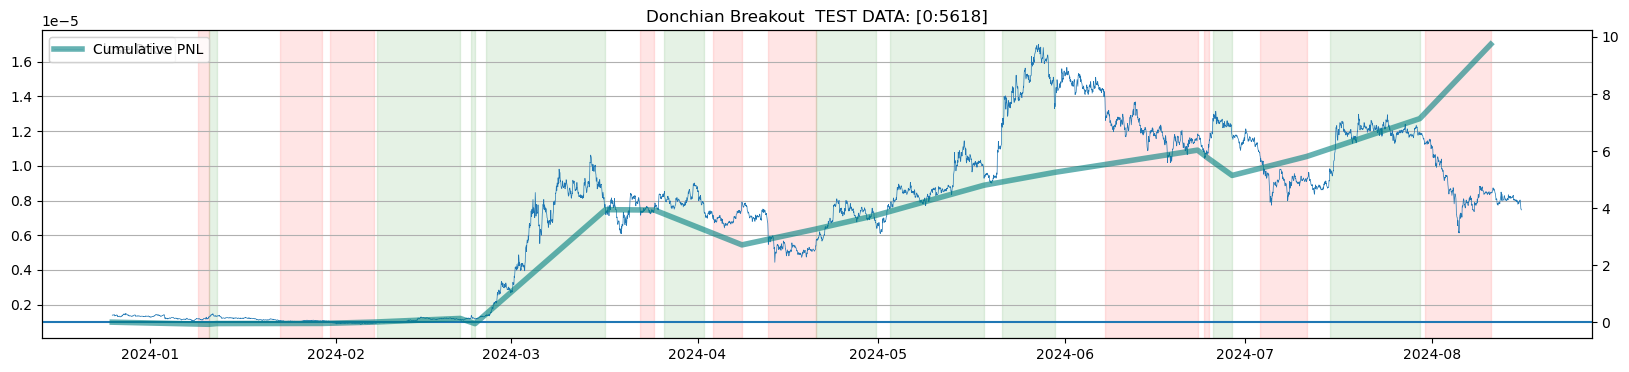

params = {'up_lookback': 155, 'dn_lookback': 157, 'up_lag': 123, 'dn_lag': 196, 'band_offset': 0.5947789836090155}
Total Return: 2.35
Asset Return: -0.54
Sharpe Ratio: 0.03
# Trades: 13
# Wins: 6
# Losses: 8
Win Ratio: 0.46
Profit Factor: 4.33
Win Ratio: 0.46
Average Win: 0.3447
Average Loss: -0.0597
Average DrawDown: -0.0526
Max DrawDown: -0.1860


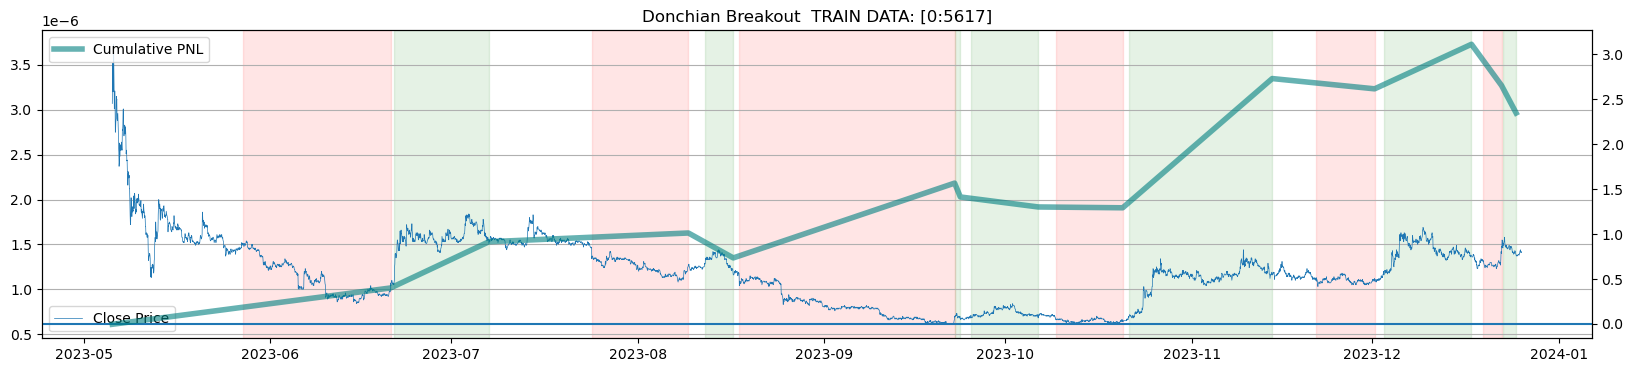

Total Return: 13.57
Asset Return: 4.33
Sharpe Ratio: 0.04
# Trades: 13
# Wins: 8
# Losses: 6
Win Ratio: 0.62
Profit Factor: 10.93
Win Ratio: 0.62
Average Win: 0.9804
Average Loss: -0.1196
Average DrawDown: -0.0979
Max DrawDown: -0.2785


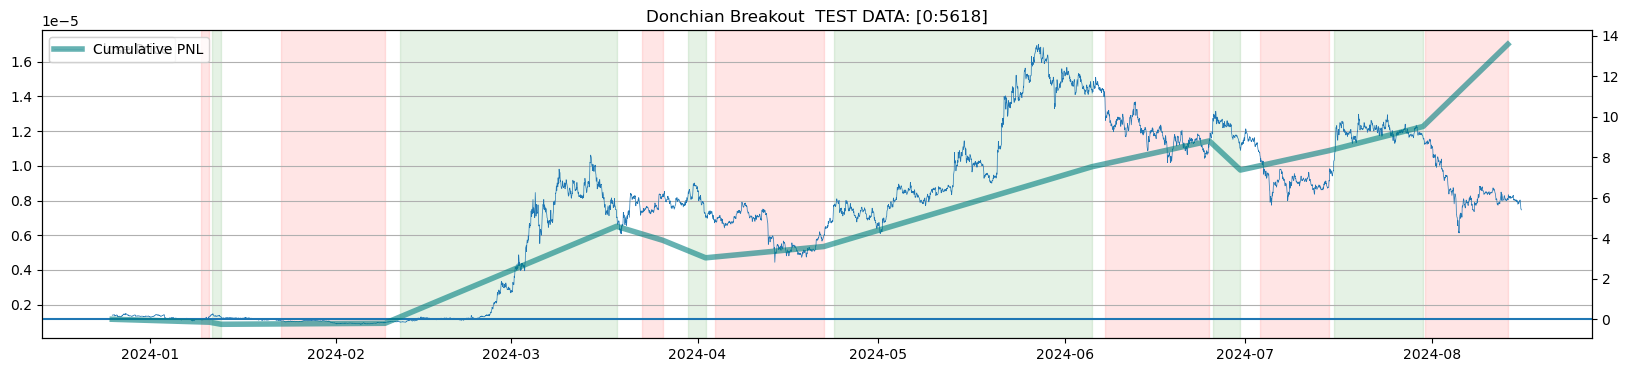

In [31]:

# Define transaction costs and slippage
transaction_cost = 0.001  # 0.1% transaction cost per trade
slippage = 0.003  # 0.1% slippage per trade

itrades = None
    
def backtest(data, params, nhours, short_long=None, xmult=1):
    if short_long is None: short_long = [1,-1]
    
    global itrades
    
    up_lookback = params['up_lookback']
    dn_lookback = params['dn_lookback']
    up_lag = params['up_lag']
    dn_lag = params['dn_lag']
    band_offset = params['band_offset']
    lclose = data['close'].apply(np.log)
    lrets = lclose.diff()

    data['donch_up'] = data['close'].rolling(window=up_lookback).max().shift(up_lag)
    data['donch_dn'] = data['close'].rolling(window=dn_lookback).min().shift(dn_lag)
    # data['donch_mid'] = (data['donch_up'] + data['donch_dn']) / 2
    data['donch_mid'] = (1 - band_offset)*data['donch_up'] + band_offset*data['donch_dn']
    # data['donch_mid_up'] = (1 - band_offset)*data['donch_up'] + band_offset*data['donch_dn']
    # data['donch_mid_dn'] = (1 - band_offset)*data['donch_dn'] + band_offset*data['donch_up']
    
    ind_undefs = data['donch_up'].isna() | data['donch_dn'].isna()
    
    bull = ( 
                    (~ind_undefs) &\
                    (data['close'] > data['donch_up']) #& \
                    # (data['donch_up'] > data['donch_dn'])
    ).astype(int)

    bull_end = ( 
                    (~ind_undefs) &\
                    (data['close'] < data['donch_mid']) #| \
                    # (data['donch_up'] < data['donch_dn'])
    ).astype(int)


    bear = ( 
                    (~ind_undefs) &\
                    (data['close'] < data['donch_dn']) #& \
                    # (data['donch_up'] < data['donch_dn'])
    ).astype(int)
    bear_end = ( 
                    (~ind_undefs) &\
                    (data['close'] > data['donch_mid']) #| \
                    # (data['donch_up'] > data['donch_dn'])
    ).astype(int)

    itrades = calculate_trades(int(1 in short_long)*bull.values, int(1 in short_long)*bull_end.values, int(-1 in short_long)*bear.values, int(-1 in short_long)*bear_end.values)
    ipositions = calculate_positions(itrades,len(lclose))

    entry_points = data.index[itrades[:,0]]
    exit_points = data.index[itrades[:,1]]
    trade_rets = pd.Series(np.append([0],itrades[:,2]*(lclose.values[itrades[:,1]] - lclose.values[itrades[:,0]])), index=data.index[np.append([0],itrades[:,1])])
    trade_rets -= (transaction_cost + slippage)
    trade_pnl = trade_rets.cumsum()
    strat_rets = lrets.shift(fill_value=0) * ipositions
    strat_pnl = strat_rets.cumsum()
    
    n_trades = len(itrades)
    # strat_rets -= data['trade'].abs() * (transaction_cost + slippage)
    data['strat_pnl'] = strat_pnl
    
    ###
    strat_rets_pct = np.exp(strat_rets) - 1
    trade_rets_pct = np.exp(trade_rets) - 1
    strat_pnl_pct = np.exp(strat_pnl) - 1
    # trade_pnl_pct = np.exp(trade_pnl) - 1
    trade_pnl_pct = (trade_rets_pct + 1).cumprod() - 1
    # Calculate performance metrics
    tot_return = trade_pnl.iloc[-1]
    tot_return_pct = np.exp(tot_return)-1
    asset_return = lclose[-1] - lclose[0]
    asset_return_pct = np.exp(asset_return) - 1
    wins = trade_rets_pct[trade_rets_pct > 0];  
    losses = trade_rets_pct[trade_rets_pct < 0]
    nwins, nlosses = len(wins), len(losses)
    win_ratio = nwins/ (n_trades) if n_trades > 0 else np.nan
    profit_factor = wins.sum() / losses.abs().sum()
    strat_rets_mean = strat_rets_pct.mean()
    sharpe = strat_rets_mean / strat_rets_pct.std()
    sortino = strat_rets_mean / losses.std()
    avg_win = wins.mean() if len(wins) > 0 else np.nan
    avg_loss = losses.mean() if len(losses) > 0 else np.nan
    
    trade_running_max = trade_pnl.cummax()
    trade_drawdowns = (trade_pnl - trade_running_max)
    trade_max_drawdown = np.min(trade_drawdowns)
    trade_drawdowns_pct = np.exp(trade_drawdowns) - 1
    trade_max_drawdown_pct = np.min(trade_drawdowns_pct)
    
    return {'tot_return':tot_return, 'tot_return_pct':tot_return_pct, 'asset_return_pct' : asset_return_pct, 'asset_return': asset_return,
            'n_trades': n_trades, 
            'nwins':nwins, 'nlosses': nlosses, 'win_ratio': win_ratio, 'profit_factor': profit_factor, 
            'sharpe': sharpe, 'sortino': sortino, 
            'entry_points': entry_points, 'exit_points': exit_points, 
            'trade_rets': trade_rets, 'trade_pnl': trade_pnl, 'strat_rets': strat_rets, 'strat_pnl': strat_pnl, 
            'trade_rets_pct': trade_rets_pct, 'trade_pnl_pct': trade_pnl_pct, 'strat_rets_pct': strat_rets_pct, 'strat_pnl_pct': strat_pnl_pct, 
            'itrades': itrades,
            'avg_win': avg_win, 'avg_loss': avg_loss,
            'trade_max_drawdown': trade_max_drawdown, 'trade_drawdowns': trade_drawdowns,
            'trade_max_drawdown_pct': trade_max_drawdown_pct, 'trade_drawdowns_pct': trade_drawdowns_pct
            # 'trade_details': trade_details 
    }

 

def optimize(data, nhours, backtest_fn = backtest, short_long=None, xmult=1):
    # Define the objective function for Optuna
    def objective(trial):
        global data
        # up_lookback = trial.suggest_int('up_lookback', 7, 1000 // (24/nhours))
        # dn_lookback = trial.suggest_int('dn_lookback', 7, 1000 // (24/nhours))
        # up_lag = trial.suggest_int('up_lag', 7, 1000 // (24/nhours))
        # dn_lag = trial.suggest_int('dn_lag', 7, 1000 // (24/nhours))
        up_lookback = trial.suggest_int('up_lookback', 7, 200)
        dn_lookback = trial.suggest_int('dn_lookback', 7, 200)
        up_lag = trial.suggest_int('up_lag', 7, 200)
        dn_lag = trial.suggest_int('dn_lag', 7, 200)
        band_offset = trial.suggest_float('band_offset', 0, 1)
        params = {
            'up_lookback': up_lookback,
            'dn_lookback': dn_lookback,
            'up_lag': up_lag,
            'dn_lag': dn_lag,
            'band_offset': band_offset
        }
        res = backtest_fn(data,params,nhours,short_long, xmult=xmult)
        return res['trade_rets'].mean(), res['trade_drawdowns_pct'].mean()#/ math.cos(number_of_trades)

    # Run the optimization
    study = optuna.create_study(directions=['maximize','maximize'])
    study.optimize(objective, n_trials=500)

    # Get the best parameters
    return study
    

def print_performance(data, nhours, best_params, backtest_fn, short_long=None, xmult=1, title=""):
    # {'tot_return':tot_return, 'n_trades': n_trades, 'nwins':nwins, 'nlosses': nlosses, 'win_ratio': win_ratio, 'profit_factor': profit_factor, 'sharpe': sharpe, 'sortino': sortino, 'entry_points': entry_points, 'exit_points': exit_points, 'trade_rets': trade_rets, 'trade_pnl': trade_pnl}
    global res
    res = backtest_fn(data,params,nhours,short_long=short_long,xmult=xmult)
    print_res(res)
    # Plot the results with the best parameters
    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 7), sharex=True, height_ratios=[2, 1])
    fig, (ax1) = plt.subplots(figsize=(20, 4))

    ax1.plot(data.index, data['close'], label='Close Price', lw=0.5)
    # ax1.plot(data.index, data['donch_up'], label='donch_up', color='blue', lw=0.5)
    # ax1.plot(data.index, data['donch_dn'], label='donch_dn', color='red', lw=0.5)
    # ax1.plot(data.index, data['donch_mid'], label='donch_mid', color='black', lw=0.5, linestyle='-')
    
    # ax1.plot(data.index, data['donch_mid_up'], label='donch_mid_up', color='black', lw=0.5, linestyle='-')
    # ax1.plot(data.index, data['donch_mid_dn'], label='donch_mid_dn', color='black', lw=0.5, linestyle='-')
    # ax1.scatter(res['entry_points'], data.loc[res['entry_points'], 'close'], marker='^', color='g', s=30, label='Entry', zorder=5, alpha=0.3)
    # ax1.scatter(res['exit_points'], data.loc[res['exit_points'], 'close'], marker='v', color='r', s=30, label='Exit', zorder=5, alpha=0.3)
    ax1.legend(loc='best')
    plt.title('Donchian Breakout  '+ title)

    ax2 = ax1.twinx()
    ax2.axhline(0)
    # ax2.plot(res['strat_pnl_pct'], label='Unrealized PNL', color='blue', alpha=0.3)
    ax2.plot(res['trade_pnl_pct'], label='Cumulative PNL', color='teal', alpha=0.6, lw=4)
    # ax2.plot(data['cum_trd_rets'].apply(np.log)-1, label='Cumulative Returns', color='blue')
    
    ax2.legend(loc='best')
    
    # for x in res['entry_points'].values: 
    #     ax1.axvline(x,color='black', lw=1, alpha=0.1)
    #     # ax2.axvline(x,color='black', lw=1, alpha=0.1)
    # for xx in res['exit_points'].values:
    #     ax1.axvline(xx,color='red', lw=1, alpha=0.1)
    #     # ax2.axvline(xx,color='red', lw=1, alpha=0.1)
    for i in range(len(itrades)):
        ax1.axvspan(xmin=data.index[itrades[i,0]],xmax=data.index[itrades[i,1]], color=['red','green'][(itrades[i,2]+1)//2],alpha=0.1)
        # ax2.axvspan(xmin=data.index[itrades[i,0]],xmax=data.index[itrades[i,1]], color=['red','green'][(itrades[i,2]+1)//2],alpha=0.1)
    
    ax1.grid(axis='y')
    # ax2.grid(axis='y')
    plt.show()

def print_res(res):
    # Print performance metrics
    print(f"Total Return: {np.exp(res['tot_return'])-1:.2f}")
    print(f"Asset Return: {np.exp(res['asset_return'])-1:.2f}")
    print(f"Sharpe Ratio: {res['sharpe']:.2f}")
    print(f"# Trades: {res['n_trades']:.0f}")
    print(f"# Wins: {res['nwins']:.0f}")
    print(f"# Losses: {res['nlosses']:.0f}")
    print(f"Win Ratio: {res['win_ratio']:.2f}")
    print(f"Profit Factor: {res['profit_factor']:.2f}")
    print(f"Win Ratio: {res['win_ratio']:.2f}")
    # print(f"Annualized Return: {results['annualized_return']:.2f}")
    print(f"Average Win: {res['avg_win']:.4f}")
    print(f"Average Loss: {res['avg_loss']:.4f}")
    print(f"Average DrawDown: {res['trade_drawdowns_pct'].mean():.4f}")
    print(f"Max DrawDown: {res['trade_max_drawdown_pct']:.4f}")
    

optuna.logging.set_verbosity(optuna.logging.ERROR)
# Load the data
# ticker = 'GOOGL'
# data = load_sp500_stock_candles(ticker)['2020':'2025']
# data['close'] = data['adj close']
# data = load_russel2000_candles('XOXO')['2006':]
data = load_candles('binance','PEPE','USDT','1h')['2022-03':'2025']#.iloc[-35000:-5000]
# # data = load_futures_candles('bybit','ALGO','USDT','1h')['2020-03':'2025']
# # data = data['2021-11-01':].copy()
nhours = 1
data = data.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
short_long = [-1,1]
train_ratio = 0.5; data_train = data.iloc[:int(data.shape[0]*train_ratio)]; data_test = data.iloc[data_train.shape[0]:]
study = optimize(data_train, nhours,backtest_fn=backtest, short_long=short_long,xmult=1)
aparams = [t.params for t in reversed(study.best_trials[-10:])]
# aparams = [{'up_lookback': 199, 'dn_lookback': 187, 'up_lag': 184, 'dn_lag': 171, 'band_offset': 0.336862108444848}, {'up_lookback': 199, 'dn_lookback': 194, 'up_lag': 178, 'dn_lag': 163, 'band_offset': 0.35936209743729997}]

print(f'aparams = {aparams}')
for params in aparams:
    print(f'params = {params}')
    print_performance(data_train,nhours,params,backtest_fn=backtest,short_long=[1,-1], xmult=1, title=f'TRAIN DATA: [0:{data_train.shape[0]-1}]')
    print_performance(data_test,nhours,params,backtest_fn=backtest,short_long=[1,-1], xmult=1, title=f'TEST DATA: [{data_test.shape[0]}:{data.shape[0]}]')

In [19]:
study.trials[90].params

{'up_lookback': 101,
 'dn_lookback': 148,
 'up_lag': 162,
 'dn_lag': 41,
 'band_offset': 0.39682833342092194}

In [21]:
params = study.trials[90].params
backtest(data,params,nhours,short_long, xmult=1)
# print_performance(data,nhours,params,backtest_fn=backtest,short_long=[1,-1], xmult=1)

{'tot_return': 3.260377729398461,
 'tot_return_pct': 25.059378677114825,
 'asset_return_pct': -0.0013639463514435457,
 'asset_return': -0.0013648773729402208,
 'n_trades': 31,
 'nwins': 14,
 'nlosses': 18,
 'win_ratio': 0.45161290322580644,
 'profit_factor': 4.845508222422277,
 'sharpe': 0.04356877138552436,
 'sortino': 0.012316812160410045,
 'entry_points': DatetimeIndex(['2020-11-14 04:00:00', '2020-12-28 12:00:00',
                '2021-04-03 00:00:00', '2021-04-23 04:00:00',
                '2021-05-14 20:00:00', '2021-05-19 12:00:00',
                '2021-08-04 12:00:00', '2021-09-22 12:00:00',
                '2021-10-09 12:00:00', '2021-10-13 16:00:00',
                '2021-11-17 00:00:00', '2022-03-26 12:00:00',
                '2022-04-17 16:00:00', '2022-07-30 04:00:00',
                '2022-08-28 00:00:00', '2022-11-04 16:00:00',
                '2022-11-09 20:00:00', '2023-01-14 04:00:00',
                '2023-03-04 00:00:00', '2023-04-13 12:00:00',
                '202

In [ ]:
# plot_optimization_history(study, target='trade_rets')
plot_param_importances(study)

In [ ]:
optuna.visualization.plot_param_importances(
    study, target=lambda t: t.duration.total_seconds(), target_name="duration"
)

In [ ]:
optuna.visualization.plot_pareto_front(study, target_names=["tot_return", "trade_max_drawdown"])

In [ ]:
plot_edf(study,target=lambda s: s.values[0])

In [ ]:
plot_rank(study,target=lambda s: s.values[0])

In [ ]:
plot_timeline(study)

In [ ]:
fig = plot_intermediate_values(study)

# fig.update_layout(
#     title="Hyperparameter optimization for Donchian Breakout strategy",
#     xaxis_title="Epoch",
#     yaxis_title="tot_return",
# )
fig

In [ ]:
for params in [t.params for t in study.best_trials]:
    print(f'params = {params}')
    print_performance(data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)

## Optimize for all assets in a portfolio

In [ ]:
import os
base_data_dir = "/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data"
quote, timeframe = 'USDT', '8h'
exchanges = ['binance', 'kucoin', 'bybit', 'bitget']
#portfolio assets
# assets = 'ADA','ALGO','ALU','AMP','APT','ARB','ATOM','AVAX','AXS','BEAM','BTC','CHZ','COQ','DOGE','DOT','EGLD','ENJ','ETH','GALA','GRT','ILV','IMX','INJ','KAS','KSM','LINK','LUNA','MANA','MATIC','MYRIA','NEAR','OP','PT','PYR','QNT','RAY','REN','RENDER','RUNE','SAND','SHIB','SNX','SOL','TET','TIA','XLM',
assets = ['BTC','ETH','BNB','SOL','XRP','USDC','ADA','AVAX','DOGE','LINK','TRX','DOT','MATIC','TON','ICP','SHIB','DAI','BCH','LTC','UNI','IMX','ATOM','ETC','APT','LEO']
# df_pf = pd.DataFrame(assets,columns=['asset'])
df_pf = pd.DataFrame([
    [(os.path.exists(f'{base_data_dir}/{exchange}/{asset}_{quote}-{timeframe}.json')) for exchange in exchanges]
    for asset in assets
]).set_axis(exchanges, axis=1)
df_pf.index = assets

df_pf['first_exch'] = df_pf.apply(lambda row: row.idxmax() if row.any() else None, axis=1)
df_pfexch = df_pf[~df_pf['first_exch'].isna()][['first_exch']]
asset_exch = df_pfexch.to_records()
# asset_files = [f'{base_data_dir}/{exchange}/{asset}_{quote}-{timeframe}.json' for (asset,exchange) in asset_exch]
asset_exch_dict = { asset:exchange for (asset,exchange) in asset_exch}
asset_exch, asset_exch_dict


In [ ]:
asset_exch

In [ ]:
short_long = [-1,1]


def optimize_params(exchange, asset, timeframe, nhours):
    def objective(trial):
        global data
        up_lookback = trial.suggest_int('up_lookback', 7, 1000 // (24/nhours))
        dn_lookback = trial.suggest_int('dn_lookback', 7, 1000 // (24/nhours))
        up_lag = trial.suggest_int('up_lag', 7, 1000 // (24/nhours))
        dn_lag = trial.suggest_int('dn_lag', 7, 1000 // (24/nhours))
        params = {
            'up_lookback': up_lookback,
            'dn_lookback': dn_lookback,
            'up_lag': up_lag,
            'dn_lag': dn_lag
        }
        res = backtest(data,params,nhours,short_long, xmult=1)
        return res['tot_return'], res['trade_max_drawdown']#
    
    data = load_candles(exchange,asset,'USDT',timeframe)['2021':'2025']#.iloc[-10000:]
    data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
    # Run the optimization
    study = optuna.create_study(directions=['maximize','maximize'])
    study.optimize(objective, n_trials=100)
    # asset_params[f'{asset}USDT'] = study.best_trials[-1].params
    # return [[t.params, t.values] for t in study.best_trials]
    return study.best_trials
nhours = 4
exchange,timeframe, = 'binance', f'{1}h'
sbest_trials = []
for (asset,exchange) in tqdm(asset_exch):
    sbest_trials.append(optimize_params(exchange, asset, timeframe, nhours))
sbest_trials

In [ ]:
import pickle
asset_trials = {asset_exch[i][0]: sbest_trials[i] for i in range(len(asset_exch))}
asset_trials
with open('portfolio-donchian-trials.pkl', 'wb') as f:
    pickle.dump(asset_trials, f)

In [ ]:
# Load the object from the file
with open('portfolio-donchian-trials.pkl', 'rb') as f:
    asset_trials = pickle.load(f)
asset_trials


In [ ]:
best_trials = [[[abt.params, abt.values] for abt in bt] for bt in sbest_trials]
best_trials

In [ ]:
trial_n = 0
df_opt = pd.DataFrame([[f'{asset_exch[i][0]}',best_trials[i][trial_n][0],best_trials[i][trial_n][1][0], best_trials[i][trial_n][1][1]] for i in range(len(asset_exch))]).set_axis(['asset','params','tot_return_pct','max_drawdown_pct'],axis=1).set_index('asset')
df_opt[['tot_return_pct','max_drawdown_pct']].agg({'tot_return_pct':[min,max,np.mean],'max_drawdown_pct':[min,max,np.mean]})
# df_opt.loc[:,['total_return','max_drawdown']] = df_opt.loc[:,['total_return','max_drawdown']].apply(np.exp).subtract(1)#.hist()


In [ ]:
df_opt.sort_values('max_drawdown_pct')

In [ ]:
df_opt[['tot_return_pct','max_drawdown_pct']].describe()

In [ ]:
pd.DataFrame(df_opt.params.to_list()).hist(bins=20,figsize=(20,4))

In [ ]:
asset_params = df_opt[['params']].to_dict()['params']
asset_params

## Randomize params and assets, test for robustness

In [ ]:
timeframe,quote,nhours ='1h', 'USDT', 4
# np.random.seed = 3
opt_backtests = [backtest(load_candles(asset_exch_dict[asset], asset, quote,timeframe)['2021':].resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}),params,nhours=nhours,short_long=[-1,1],xmult=1) for (asset, params) in list(zip(df_opt.index,np.random.permutation(df_opt['params'].values))) ]


In [ ]:

rand_backtests = pd.DataFrame([{k:v for (k,v) in opt_bt.items() if not (isinstance(v,pd.Series) or isinstance(v,pd.Index)  or isinstance(v,np.ndarray))} for opt_bt in opt_backtests], index=df_pfexch.index)
rand_backtests.sort_values('tot_return').tail()

In [ ]:
rand_backtests[['tot_return_pct','trade_max_drawdown_pct']].describe()


In [ ]:
rand_backtests.hist(bins=50,figsize=(20,8))
plt.tight_layout()

## Simulate 100 randomized parameter set picks

In [ ]:
## Run a bunch of randomized simulations
timeframe,quote,nhours ='1h', 'USDT', 8
ran_sumul = []
for i in tqdm(range(10)):
    opt_backtests = [backtest(load_candles(asset_exch_dict[asset], asset, quote,timeframe)['2021':].resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}),params,nhours=nhours,short_long=[1],xmult=1) for (asset, params) in list(zip(df_opt.index,np.random.permutation(df_opt['params'].values))) ]
    ran_backtests = pd.DataFrame([{k:v for (k,v) in opt_bt.items() if not (isinstance(v,pd.Series) or isinstance(v,pd.Index)  or isinstance(v,np.ndarray))} for opt_bt in opt_backtests], index=df_pfexch.index)
    ran_sumul.append(ran_backtests[['tot_return_pct','trade_max_drawdown_pct']].describe().to_dict())
    
# np.histogram(ran_sumul)


In [ ]:
ran_sumul
# pd.DataFrame.from_records(ran_sumul)
# simul_rets = pd.Series(ran_sumul)
# simul_rets.describe(),simul_rets.hist(bins=50)

In [ ]:

opt_backtests = [print_performance(load_candles(asset_exch_dict[asset], asset, quote,timeframe)['2021':],nhours,params,backtest,short_long=[-1,1],xmult=1) for (asset, params) in list(zip(df_opt.index,np.random.permutation(df_opt['params'].values))) ]

## Generate pinescript for a bunch of assets

In [ ]:
assets = ['ADA', 'ALGO', 'DOT', 'LINK', 'SOL']
exchange = 'BINANCE'
def objective(trial):
    global data
    up_lookback = trial.suggest_int('up_lookback', 7, 100)
    dn_lookback = trial.suggest_int('dn_lookback', 7, 100)
    up_lag = trial.suggest_int('up_lag', 7, 100)
    dn_lag = trial.suggest_int('dn_lag', 7, 100)
    params = {
        'up_lookback': up_lookback,
        'dn_lookback': dn_lookback,
        'up_lag': up_lag,
        'dn_lag': dn_lag
    }
    res = backtest(data,params,nhours,short_long, xmult=1)
    return res['tot_return'], res['trade_max_drawdown']#/ math.cos(number_of_trades)
nhours = 1
# data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
short_long = [1]
asset_params = {}
for asset in assets:
    data = load_candles('binance',asset,'USDT','8h')#['2011':'2025']#.iloc[-10000:]
    # Run the optimization
    study = optuna.create_study(directions=['maximize','maximize'])
    study.optimize(objective, n_trials=100)
    asset_params[f'{asset}USDT'] = study.best_trials[-1].params

In [ ]:
asset_params

In [ ]:
from jinja2 import Template
quote = 'USDT'
# Define the template (could also be loaded from a .jinja2 file)
template_str = """
//@version=5
indicator("Custom Donchian with Asset-Specific Parameters", overlay=true)

up_lag = 20
up_lookback = 20
dn_lag = 20
dn_lookback = 20
split_string = str.split(ticker.standard(),":")
string tkr = split_string.last()
// Determine parameters based on asset
{% for asset, params in asset_params.items() %}
if (tkr == "{{ asset }}{{ quote }}")
    up_lag := {{ params.up_lag }}
    dn_lag := {{ params.dn_lag }}
    up_lookback := {{ params.up_lookback }}
    dn_lookback := {{ params.dn_lookback }}
{% endfor %}

// Upper Donchian Band: Highest high over the up_lookback period, shifted by donch_up periods
upper_band = ta.highest(high, up_lookback)[up_lag]
// Lower Donchian Band: Lowest low over the dn_lookback period, shifted by donch_dn periods
lower_band = ta.lowest(low, dn_lookback)[dn_lag]
// Middle line between the upper and lower bands
middle_line = (upper_band + lower_band) / 2

// Plotting the upper and lower bands
plot(upper_band, title="Upper Donchian Band", color=color.green, linewidth=2)
plot(lower_band, title="Lower Donchian Band", color=color.red, linewidth=2)
plot(middle_line, title="Middle Line", color=color.gray, linewidth=2)

"""

template_str2 = """
bla
{% for asset in assets %}
 "{{ asset }}"
{% endfor %}
"""
# Create a template object
template = Template(template_str)

# Render the template with the asset_params dictionary
rendered_pine_script = template.render(asset_params=asset_params, quote=quote)

# Output the generated Pine Script
print(rendered_pine_script)



## Split data into training and testing set

In [ ]:
np.min([params[k] for k in params])

In [ ]:

data = load_candles('binance','BTC','USDT','1h')#.iloc[-5000:]
# data = load_futures_candles('bybit','ALGO','USDT','1h')['2020-03':'2025']
# data = data['2021-11-01':].copy()
nhours = 8
data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
short_long = [-1,1]

train_ratio = 0.3; 
cutoff = int(train_ratio * data.shape[0])
train_data, test_data = data.iloc[:cutoff,:], data.iloc[cutoff+1-np.max([params[k] for k in params]):,:]

study = optimize(train_data, nhours,backtest_fn=backtest, short_long=short_long)
params = study.best_params
params = {'tenkan_period': 19, 'kijun_period': 22, 'senkou_span_b_period': 22}
print(f'params = {params}')
print_performance(test_data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)
print_performance(train_data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)
print(f'params = {params}')

In [ ]:
train_data

## Backtest in a LOOP

In [ ]:
   
def backtest(data, nhours, short_long=None, xmult=1):
    if short_long is None: short_long = [1,-1]

    # Initialize the 'position' column
    data['position'] = 0
    
    # # Set the 'position' column based on the signals
    if 1 in short_long:
        data.loc[data['bull'], 'position'] = 1        
        data.loc[(data['bull'] & data['bull_exit']), 'position'] = 0   
    # Exit position when exit signal is True
    
    # Set the 'position' column based on the signals
    if -1 in short_long:
        data.loc[(data['bear']), 'position'] = -1    
        data.loc[(data['bear'] & data['bear_exit']), 'position'] = 0
    ###    
    # data['position'] = xmult*(int(1 in short_long) * (data['bull'] &~ data['bull_exit'])) - (int(-1 in short_long) * (data['bear'] &~ data['bear_exit']))
    positions_shifted = data['position'].shift()#.fillna(0).astype(int)
    data['trade'] = data['position'].diff()#.fillna(0).astype(int)
    data.at[data.index[-1],'trade'] = -data.iloc[-1]['position']
    data['strategy_returns'] = positions_shifted * (data['lclose'].diff().fillna(0))
    number_of_trades = data['trade'].abs().sum()
    data['strategy_returns'] -= data['trade'].abs() * (transaction_cost + slippage)
    data['cumulative_returns'] = data['strategy_returns'].cumsum()
    
    data['pct_strategy_returns'] = np.exp(data['strategy_returns']) -1
    data['pct_cumulative_returns'] = np.exp(data['cumulative_returns']) -1
    ###
    
    
    # Apply transaction costs and slippage only on trades
    # data['strategy_returns'] -= data['trade'] * (transaction_cost + slippage)

    
    # Calculate performance metrics
    total_return = data['pct_cumulative_returns'].iloc[-1]
    annualized_return = data['pct_strategy_returns'].mean() * 365 * 24 / 8  # Assuming 8-hour bars
    annualized_volatility = data['pct_strategy_returns'].std() * np.sqrt(365 * 24 / nhours)
    sharpe_ratio = annualized_return / annualized_volatility
    

## Forward Testing

In [ ]:
# data = load_futures_candles('bybit','ADA','USDT','1h')['2020':'2023']
data = load_candles('binance','BTC','USDT','1h')['2020':'2025']
ohlc_dict = {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}
nhours = 8 ; ntrain = 3 ; ndays = 30
short_long = [1]
data = data.resample(f'{nhours}H').agg(ohlc_dict)#[:'2022']
n = data.shape[0]
w = (24 // nhours) * ndays
fwd_params = []
for i in tqdm(range(ntrain, (n // w)-1)):
    fwd_params.append(optimize(data.iloc[(i-ntrain)*w:(i)*w-1], nhours, short_long=short_long,xmult=1).best_params)
    

In [ ]:
df_params = pd.DataFrame(fwd_params)
df_params.describe()

In [ ]:


bt_arr = []; res_arr =[]
for i in tqdm(range(ntrain, (n // w)-1)):    
    # print(i)
    wdata = indicators(data.iloc[i*w:(i+1)*w],fwd_params[i-ntrain])
    results = backtest(wdata,nhours,short_long)
    decorate_trades(wdata)
    bt_arr.append(wdata)
    res_arr.append(results)

In [ ]:
data.shape[0], w, i, i*w, (i+1)*w

In [ ]:
df_res = pd.DataFrame(res_arr)
df_res#.describe()

In [ ]:
df_res.sharpe_ratio.mean(), (1+df_res.total_return).cumprod().values[-1], df_res.number_of_trades.sum()

In [ ]:
df_trd = pd.concat(bt_arr)
ax = df_trd['pct_strategy_returns'].add(1).cumprod().subtract(1).plot()
# df_trd['pct_cumulative_returns'].plot(ax=ax)

In [ ]:
df_trd

In [ ]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}

data = data.resample(f'{8}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1,1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

## Test different Timeframes with resampling

In [ ]:
data = load_candles('ALGO','USDT','1h')#['2021-04':]
ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
test_results = []
short_long=[-1,1]
resample_periods = np.arange(5,100,1)
for i in tqdm(resample_periods, desc="Processing"):
    rdata = data.resample(f'{i}H').agg(ohlc_dict)
    study = optimize(rdata, short_long=short_long)
    test_results.append(study)


In [ ]:
# data = load_candles('PEPE','USDT','2h')#['2021-04':]
rparams = [study.best_params for study in test_results]
rbacktests = []
short_long=[-1,1]
for i in tqdm(range(len(resample_periods))):
    rdata = data.iloc[5:].resample(f'{resample_periods[i]}H').agg(ohlc_dict)
    params = test_results[i].best_params
    rdata = indicators(rdata, params)
    test_result = backtest(rdata, short_long)
    decorate_trades(rdata)
    rbacktests.append(test_result)
    

             
# [(resample_periods[i],rbacktests[i][1]) for i in range(len(rbacktests))]

In [ ]:

suffixes = ['_suffix', '_suffix2']

# Function to remove suffixes from a key
def remove_suffixes(key, suffixes):
    for suffix in suffixes:
        if key.endswith(suffix):
            return key[:-len(suffix)]
    return key

# Function to remove the suffixes from dictionary keys
def remove_suffixes_from_dict(d, suffixes):
    return {remove_suffixes(key, suffixes): value for key, value in d.items()}

dfres = pd.DataFrame([{'period': i, 'days':int(i*2/24),  **(remove_suffixes_from_dict(d1.best_params, ['_len'])), **d2} for i, d1, d2 in zip(resample_periods,test_results, rbacktests)])

dfres.head(10)

dfres.sort_values(by='total_return', axis=0, ascending=False).head(10)

In [ ]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
i = 6
data = data.resample(f'{resample_periods[i]}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

In [ ]:

# Calculate Ichimoku Cloud components
def ichimoku_cloud_log(data, tenkan_period=9, kijun_period=26, senkou_span_b_period=52):
    data['tenkan_sen'] = data['close'].rolling(window=tenkan_period).mean()
    data['kijun_sen'] = data['close'].rolling(window=kijun_period).mean()
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(kijun_period)
    data['senkou_span_b'] = data['close'].rolling(window=senkou_span_b_period).mean().shift(kijun_period)
    return data.dropna()

# Define trading signals
def ichimoku_trading_signals(data):
    buy_signals = (data['tenkan_sen'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_a']) & \
                  (data['close'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_b'])

    sell_signals = (data['close'] < data['senkou_span_a']) | \
                   (data['close'] < data['senkou_span_b'])

    return buy_signals.shift(1).fillna(False), sell_signals.shift(1).fillna(False)

# Fully vectorized backtest without holding period
def fully_vectorized_backtest_no_holding_period(data, buy_signals, sell_signals):
    position = np.zeros(len(data))
    returns = np.ones(len(data))

    for i in range(1, len(data)):
        if buy_signals.iloc[i] and position[i - 1] == 0:
            position[i] = 1  # Buy signal, enter position
        elif position[i - 1] > 0:
            position[i] = 1  # Maintain position

            if sell_signals.iloc[i]:
                returns[i] = data['close'].iloc[i] / data['close'].iloc[np.where(position[:i])[0][-1]]  # Calculate return
                position[i] = 0  # Exit position
        else:
            returns[i] = 1  # No trade, no return

    cumulative_returns = pd.Series(np.cumprod(returns), index=data.index)
    return cumulative_returns

# Genetic Algorithm for parameter optimization
def genetic_algorithm(num_generations, population_size, num_parents):
    # Define the parameter space
    tenkan_range = (5, 30)
    kijun_range = (20, 60)
    senkou_span_b_range = (40, 120)

    # Initialize population
    def initialize_population(size):
        population = []
        for _ in range(size):
            individual = [
                np.random.randint(*tenkan_range),
                np.random.randint(*kijun_range),
                np.random.randint(*senkou_span_b_range)
            ]
            population.append(individual)
        return population

    # Fitness function
    def fitness_function(individual):
        tenkan_period, kijun_period, senkou_span_b_period = individual
        temp_data = ichimoku_cloud_log(data.copy(), tenkan_period, kijun_period, senkou_span_b_period)
        buy_signals, sell_signals = ichimoku_trading_signals(temp_data)
        cumulative_returns = fully_vectorized_backtest_no_holding_period(temp_data, buy_signals, sell_signals)
        final_cumulative_return = cumulative_returns.iloc[-1]
        return final_cumulative_return

    # Selection
    def select_parents(population, fitnesses, num_parents):
        normalized_fitnesses = np.array(fitnesses) / np.sum(fitnesses)
        parents = np.random.choice(np.arange(len(population)), size=num_parents, replace=False, p=normalized_fitnesses)
        return [population[parent] for parent in parents]

    # Crossover
    def crossover(parents):
        offspring = []
        for i in range(0, len(parents), 2):
            parent1 = parents[i]
            parent2 = parents[(i + 1) % len(parents)]
            crossover_point = np.random.randint(1, len(parent1))
            child1 = parent1[:crossover_point] + parent2[crossover_point:]
            child2 = parent2[:crossover_point] + parent1[crossover_point:]
            offspring.extend([child1, child2])
        return offspring

    # Mutation
    def mutate(offspring):
        for individual in offspring:
            if np.random.rand() < 0.1:
                mutation_point = np.random.randint(len(individual))
                if mutation_point == 0:
                    individual[mutation_point] = np.random.randint(*tenkan_range)
                elif mutation_point == 1:
                    individual[mutation_point] = np.random.randint(*kijun_range)
                elif mutation_point == 2:
                    individual[mutation_point] = np.random.randint(*senkou_span_b_range)
        return offspring

    # Genetic Algorithm
    population = initialize_population(population_size)
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(num_generations):
        with ThreadPoolExecutor() as executor:
            fitnesses = list(executor.map(fitness_function, population))
        best_generation_fitness = max(fitnesses)
        best_generation_individual = population[fitnesses.index(best_generation_fitness)]
        
        if best_generation_fitness > best_fitness:
            best_fitness = best_generation_fitness
            best_individual = best_generation_individual
        
        if generation % 2 == 0 or generation == num_generations - 1:
            print(f"Generation {generation}: Best Fitness = {best_fitness}")
        
        parents = select_parents(population, fitnesses, num_parents)
        offspring = crossover(parents)
        offspring = mutate(offspring)
        population = parents + offspring

    return best_individual, best_fitness

# Run the genetic algorithm
best_signal_params_ga, best_cumulative_return_signal_ga = genetic_algorithm(num_generations=10, population_size=10, num_parents=5)
print(f"Best Parameters: {best_signal_params_ga}, Best Cumulative Return: {best_cumulative_return_signal_ga}")

# Apply the optimized parameters to the strategy
optimized_data_ga = ichimoku_cloud_log(data.copy(), best_signal_params_ga[0], best_signal_params_ga[1], best_signal_params_ga[2])
buy_signals, sell_signals = ichimoku_trading_signals(optimized_data_ga)

# Apply the optimized backtest strategy without holding period
cumulative_returns_optimized_ga = fully_vectorized_backtest_no_holding_period(optimized_data_ga, buy_signals, sell_signals)

# Plot the cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns_optimized_ga, label='Cumulative Returns (Optimized Buy Signals)')
plt.title('Ichimoku Trading Strategy Cumulative Returns (Optimized Buy Signals)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# Calculate risk metrics
def calculate_risk_metrics(cumulative_returns):
    returns = cumulative_returns.pct_change().dropna()
    sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252 * 24 / 8)
    max_drawdown = (cumulative_returns / cumulative_returns.cummax() - 1).min()
    return sharpe_ratio, max_drawdown

sharpe_ratio, max_drawdown = calculate_risk_metrics(cumulative_returns_optimized_ga)
print(f"Sharpe Ratio: {sharpe_ratio}, Max Drawdown: {max_drawdown}")
